# Assignment 5

In the previous exercises you have gotten detailed instructions about how to solve a predictive task step-by-step. In this week's exercise it will be the opposite: You are given full freedom to do as you choose, given that you are able to solve the task at hand relatively well, and reflect on your choices. The idea is that this should resemble what would happen in a real-life project, be it in research or in the industry: Then you will have few a priori answers to what preprocessing steps are necessary or what model is the best, but you will need to make choices, revise them as you go, and reflect upon the process afterwards.
The task is as follows:

# 1. Preprocess and check

Preprocess the dataset as you see fit.
- Fit non-linear models (GLM, GAM, RF, XGBoost) to predict Balance from the other variables in the dataset. You are not allowed to use the Income variable as a predictor, due to its high collinearity with Balance.
- Whether you fit one or more types of models is up to you, the same goes for the choice of hyperparameters and how you find them. However, you should aim for achieving good predictive performance, and being relatively certain the performance holds up in new data.
- In other words, using a train/validation/test-split or a (nested) cross-validation is probably a good idea. When you are satisfied, report model performance in a comprehensible manner.

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV, KFold
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from pygam import LinearGAM

In [32]:
# Load data
df = pd.read_csv("Credit.csv")

# Drop Income
df = df.drop("Income", axis=1)

# Convert Yes/No to 1/0
binary_cols = ["Own", "Student", "Married"]
for col in binary_cols:
    df[col] = (df[col] == "Yes").astype(int)

# One-hot encode Region
df = pd.get_dummies(df, columns=["Region"], drop_first=True)

# Separate features and target
X = df.drop("Balance", axis=1)
y = df["Balance"]

# Train/Val/Test split (60/20/20)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)

print(f"Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train: 240, Val: 80, Test: 80


In [33]:
print("Training set shape:", X_train.shape)
print("\nFirst few rows:")
print(X_train.head())

print("-" * 50)

# Check for missing values
print("Missing values:")
print(df.isnull().sum())

# Check for outliers in numeric columns
print("\nNumeric features summary:")
print(X_train.describe())

Training set shape: (240, 10)

First few rows:
     Limit  Rating  Cards  Age  Education  Own  Student  Married  \
96    5382     367      1   59         17    0        1        0   
277   5000     353      2   50         12    0        0        1   
307   3874     298      3   41         14    1        0        1   
337    855     119      3   32         12    0        0        1   
248    905      93      1   38         16    0        1        1   

     Region_South  Region_West  
96          False         True  
277          True        False  
307         False         True  
337         False        False  
248          True        False  
--------------------------------------------------
Missing values:
Limit           0
Rating          0
Cards           0
Age             0
Education       0
Own             0
Student         0
Married         0
Balance         0
Region_South    0
Region_West     0
dtype: int64

Numeric features summary:
              Limit      Rating       Car

## Check linear models first

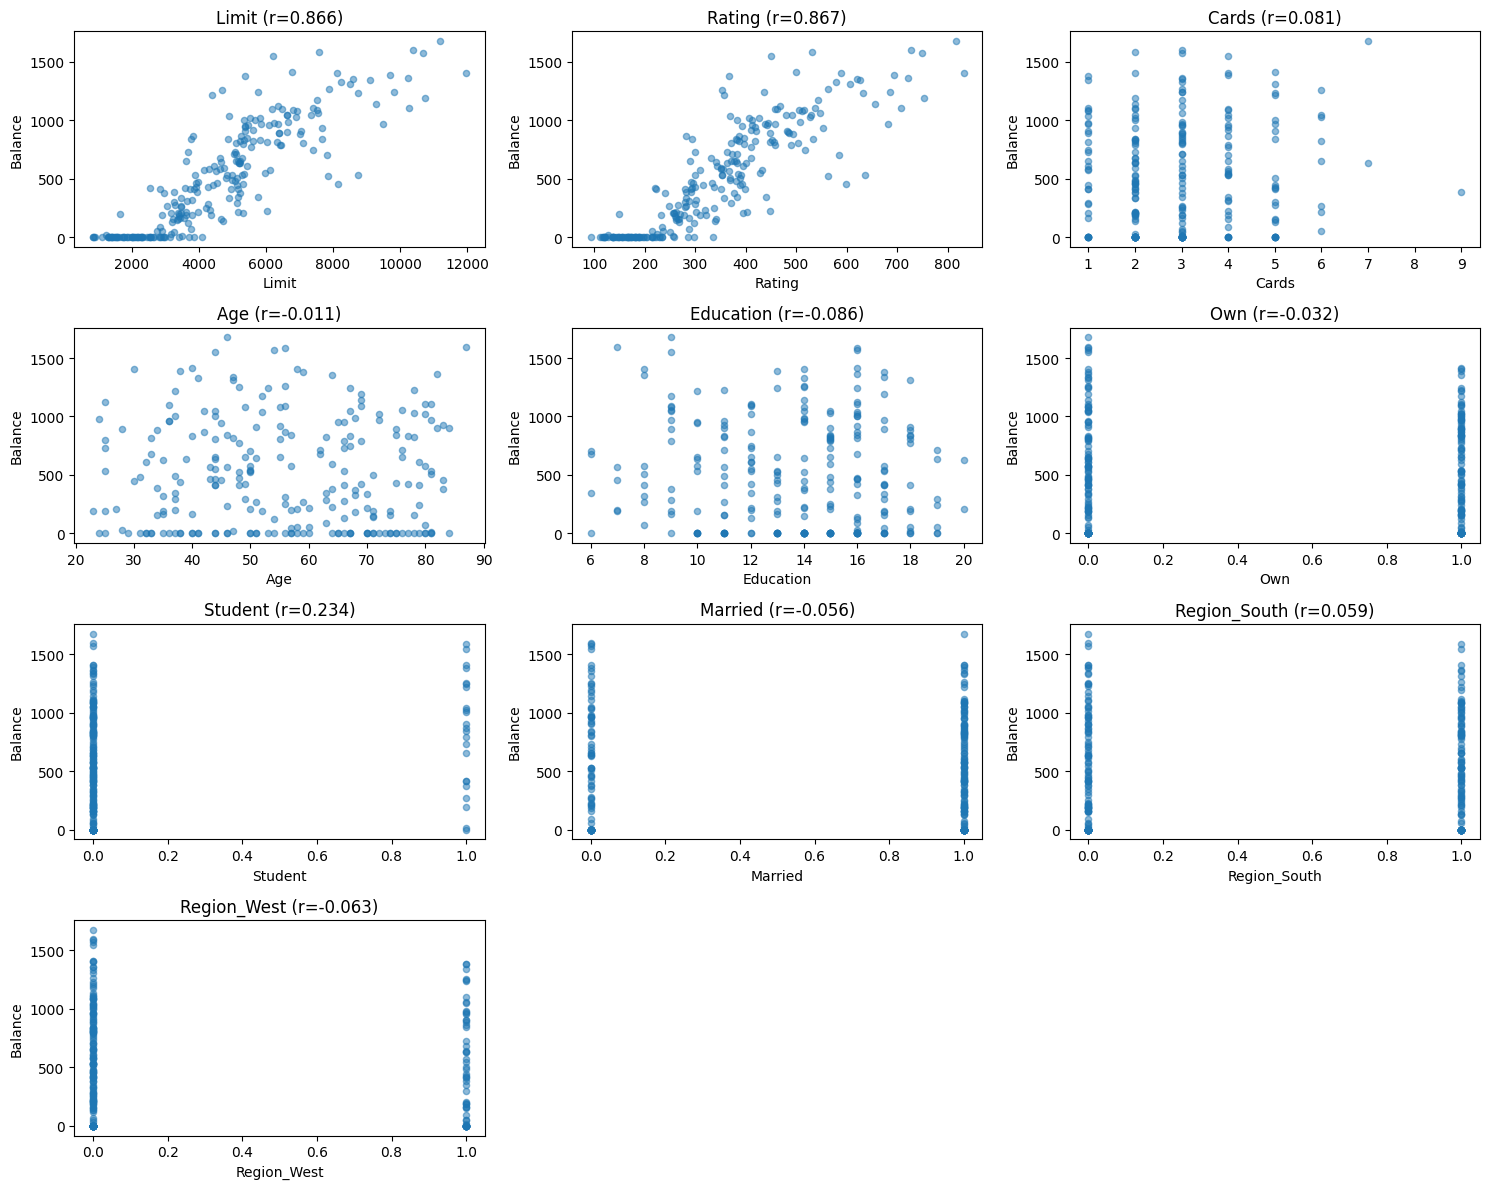

In [34]:
# All features in scatter plot grid
n_features = len(X_train.columns)
n_cols = 3
n_rows = (n_features + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

correlations = X_train.corrwith(y_train)

for idx, feature in enumerate(X_train.columns):
    axes[idx].scatter(X_train[feature], y_train, alpha=0.5, s=20)
    axes[idx].set_xlabel(feature)
    axes[idx].set_ylabel("Balance")
    axes[idx].set_title(f"{feature} (r={correlations[feature]:.3f})")

# Hide unused subplots
for idx in range(n_features, len(axes)):
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

Correlations with balance
Rating         :  0.867
Limit          :  0.866
Student        :  0.234
Education      : -0.086
Cards          :  0.081
Region_West    : -0.063
Region_South   :  0.059
Married        : -0.056
Own            : -0.032
Age            : -0.011


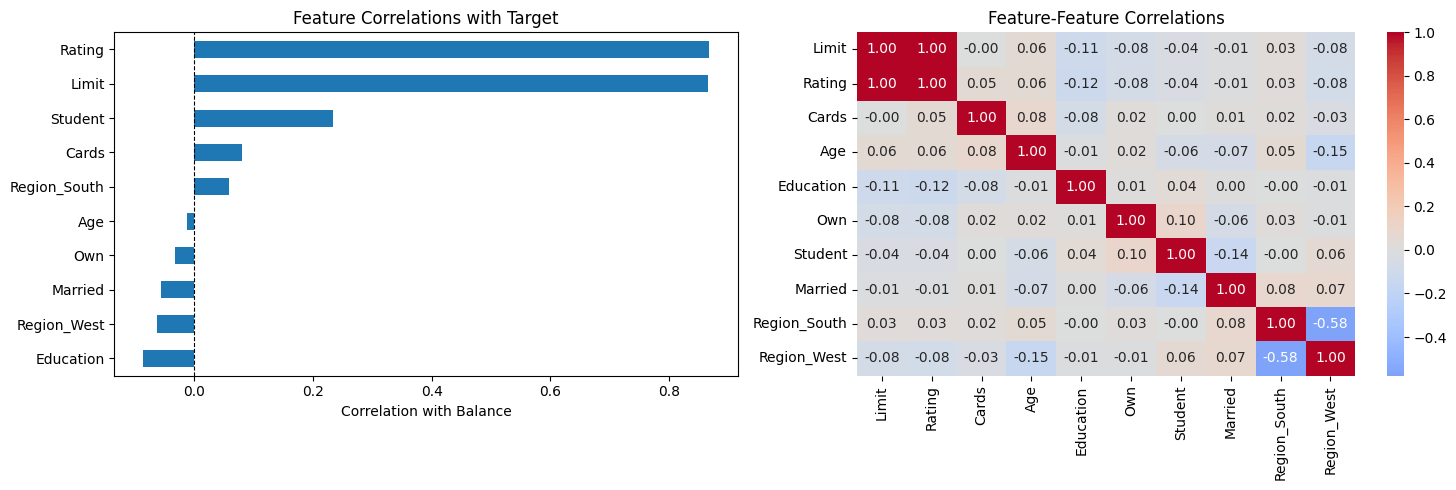

In [35]:
# 1. Correlation with target
print("Correlations with balance")
correlations = X_train.corrwith(y_train).sort_values(key=abs, ascending=False)
for feature, corr in correlations.items():
    print(f"{feature:15s}: {corr:6.3f}")

# 2. Visualize correlations
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# Bar plot
correlations.sort_values().plot(kind="barh", ax=ax1)
ax1.set_xlabel("Correlation with Balance")
ax1.set_title("Feature Correlations with Target")
ax1.axvline(x=0, color="black", linestyle="--", linewidth=0.8)

# Feature-feature correlation heatmap (to check multicollinearity)
import seaborn as sns

corr_matrix = X_train.corr()
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax2)
ax2.set_title("Feature-Feature Correlations")

plt.tight_layout()
plt.show()

## 2. Fit and tune models

In [ ]:
# 1. GAM Hyperparameter Tuning (manual CV)
X_train_int = X_train.astype(int)
X_val_int = X_val.astype(int)
param_grid = {"lam": np.logspace(-2, 3, 10), "n_splines": [10, 15, 20, 25]}
best_score = float("inf")
best_params = None
best_gam = None
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for lam in param_grid["lam"]:
    for n_splines in param_grid["n_splines"]:
        cv_scores = []
        for train_idx, val_idx in kf.split(X_train_int):
            X_fold_train, X_fold_val = X_train_int.iloc[train_idx], X_train_int.iloc[val_idx]
            y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]
            gam = LinearGAM(lam=lam, n_splines=n_splines).fit(X_fold_train, y_fold_train)
            pred = gam.predict(X_fold_val)
            cv_scores.append(np.sqrt(mean_squared_error(y_fold_val, pred)))
        mean_score = np.mean(cv_scores)
        if mean_score < best_score:
            best_score = mean_score
            best_params = {"lam": lam, "n_splines": n_splines}
            best_gam = LinearGAM(lam=lam, n_splines=n_splines).fit(X_train_int, y_train)

print(f"GAM - Best params: {best_params}, CV RMSE: {best_score:.2f}")

# 2. GLM with Pipeline (StandardScaler + PolynomialFeatures + Ridge)
glm_pipe = Pipeline(
    [("scaler", StandardScaler()), ("poly", PolynomialFeatures(degree=2, include_bias=False)), ("ridge", Ridge())]
)
glm_params = {"ridge__alpha": [0.01, 0.1, 1, 10, 100, 1000]}
glm_search = GridSearchCV(glm_pipe, glm_params, cv=5, scoring="neg_root_mean_squared_error")
glm_search.fit(X_train, y_train)

# 3. Random Forest
rf_params = {"n_estimators": [100, 200, 300], "max_depth": [10, 20, 30, None], "min_samples_split": [2, 5, 10]}
rf_search = RandomizedSearchCV(
    RandomForestRegressor(random_state=42),
    rf_params,
    n_iter=20,
    cv=5,
    scoring="neg_root_mean_squared_error",
    random_state=42,
)
rf_search.fit(X_train, y_train)

# 4. XGBoost
xgb_params = {"n_estimators": [50, 100, 200], "max_depth": [3, 5, 7], "learning_rate": [0.01, 0.05, 0.1]}
xgb_search = RandomizedSearchCV(
    XGBRegressor(random_state=42), xgb_params, n_iter=20, cv=5, scoring="neg_root_mean_squared_error", random_state=42
)
xgb_search.fit(X_train, y_train)

# Validation set performance
print(f"\nValidation Results:")
print(f"GAM - RMSE: {np.sqrt(mean_squared_error(y_val, best_gam.predict(X_val_int))):.2f}")
for name, search in [("GLM", glm_search), ("RF", rf_search), ("XGBoost", xgb_search)]:
    pred = search.predict(X_val)
    print(f"{name} - RMSE: {np.sqrt(mean_squared_error(y_val, pred)):.2f}")

## Models on test set

In [ ]:
# Test set evaluation for all models
X_test_int = X_test.astype(int)

results = {}
# GAM
test_pred = best_gam.predict(X_test_int)
results["GAM"] = {
    "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
    "MAE": mean_absolute_error(y_test, test_pred),
    "R²": r2_score(y_test, test_pred),
}

# Other models
for name, model in [
    ("GLM", glm_search.best_estimator_),
    ("RF", rf_search.best_estimator_),
    ("XGBoost", xgb_search.best_estimator_),
]:
    test_pred = model.predict(X_test)
    results[name] = {
        "RMSE": np.sqrt(mean_squared_error(y_test, test_pred)),
        "MAE": mean_absolute_error(y_test, test_pred),
        "R²": r2_score(y_test, test_pred),
    }

# Display results
for name, metrics in results.items():
    print(f"{name}:")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  MAE: {metrics['MAE']:.2f}")
    print(f"  R²: {metrics['R²']:.3f}\n")

GAM:
  RMSE: 213.41
  MAE: 163.70
  R²: 0.727

GLM:
  RMSE: 234.46
  MAE: 174.33
  R²: 0.671

RF:
  RMSE: 220.13
  MAE: 157.73
  R²: 0.710

XGBoost:
  RMSE: 208.54
  MAE: 156.27
  R²: 0.740



## Plot models on test set

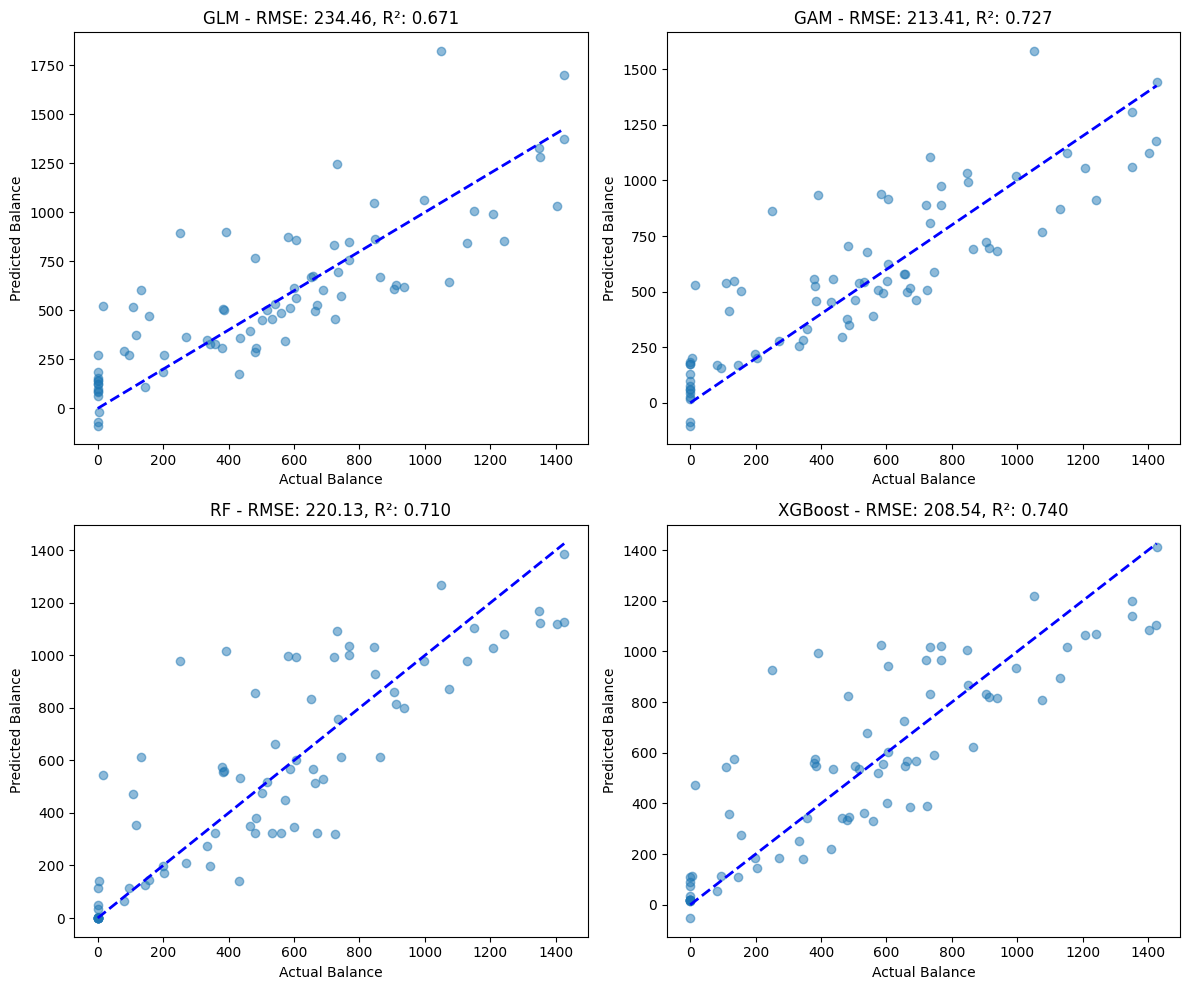

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

models_list = [
    ("GLM", glm_search.best_estimator_, X_test),
    ("GAM", best_gam, X_test_int),
    ("RF", rf_search.best_estimator_, X_test),
    ("XGBoost", xgb_search.best_estimator_, X_test),
]

for idx, (name, model, X_data) in enumerate(models_list):
    pred = model.predict(X_data)
    rmse = np.sqrt(mean_squared_error(y_test, pred))
    r2 = r2_score(y_test, pred)

    axes[idx].scatter(y_test, pred, alpha=0.5)
    axes[idx].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "b--", lw=2)
    axes[idx].set_xlabel("Actual Balance")
    axes[idx].set_ylabel("Predicted Balance")
    axes[idx].set_title(f"{name} - RMSE: {rmse:.2f}, R²: {r2:.3f}")

plt.tight_layout()
plt.show()

## 3.

- Reflect on the choices you made: Why did you choose the model(s) you did? What about the hyperparameters? How did you tune them?
- Reflect upon the performance of the model(s): How well did it/they perform? What would you expect the performance to be on new data? How can you argue this is the case? What other choices could have made you more or less certain about this?